# 🧪 Preparcial – Caso de Negocio “YumFit”
## Escenario
Eres el/la **Chief Marketing Officer (CMO)** de **YumFit**, una start-up que vende snacks saludables 100 % online.  
Tu equipo de Data te entrega un dataset con historial de 150 clientes (`df`) y te aprueban un presupuesto de **US$10 000** para la próxima campaña de retención y cross-selling.

### Misión
Sigue el **paso a paso** y toma decisiones que evolucionan de lo descriptivo a la recomendación táctica:
1. Conocer la base de clientes → *EDA*  
2. Calcular **CAC** y **LTV** → *Métricas de negocio*  
3. Segmentar en **4 clusters** con *K-Means* → *Inteligencia de clientes*  
4. Evaluar el valor de cada cluster → *Trade-offs*  
5. Hacer **profiling** (nombre + storytelling) → *Comunicación*  
6. Asignar presupuesto y justificar → *Decisión ejecutiva*

---
### Instrucciones
Ejecuta cada celda, responde las preguntas (P1…P12) y prepara un informe ejecutivo breve al final.

In [1]:
!wget "https://github.com/javierherrera1996/IntroMarketingAnalytics/raw/refs/heads/main/SegundoCorte/clientes_segmentos%20(1).csv"

--2025-05-01 00:13:11--  https://github.com/javierherrera1996/IntroMarketingAnalytics/raw/refs/heads/main/SegundoCorte/clientes_segmentos%20(1).csv
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/javierherrera1996/IntroMarketingAnalytics/refs/heads/main/SegundoCorte/clientes_segmentos%20(1).csv [following]
--2025-05-01 00:13:11--  https://raw.githubusercontent.com/javierherrera1996/IntroMarketingAnalytics/refs/heads/main/SegundoCorte/clientes_segmentos%20(1).csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 738615 (721K) [text/plain]
Saving to: ‘clientes_segmentos (1).csv’

clientes_segmentos 

In [2]:
import pandas as pd
df = pd.read_csv('clientes_segmentos (1).csv')

In [3]:
df.head()

,id_cliente,edad,genero,ingresos,plataforma,interacciones,compras,total_gastado,fecha_ultima_compra,costo_adquisicion
0,C00000,24,M,29869,Instagram,35,2,74,2024-12-25,20
1,C00001,38,M,77827,Instagram,36,1,35,2025-01-24,10
2,C00002,39,M,18000,Instagram,25,2,116,2025-01-18,16
3,C00003,20,F,42914,Instagram,29,4,112,2025-03-14,11
4,C00004,38,M,30536,Instagram,33,3,147,2025-01-01,23


### P1. ¿Cuántos clientes hay y cómo se distribuyen por plataforma?


In [4]:
import pandas as pd

# URL del dataset (Corrected URL)
url = 'https://github.com/javierherrera1996/IntroMarketingAnalytics/raw/refs/heads/main/SegundoCorte/clientes_segmentos%20(1).csv'

# Cargar el dataset en un DataFrame de pandas
df = pd.read_csv(url)

# Mostrar la cantidad total de clientes
total_clientes = len(df)
print(f"Cantidad total de clientes: {total_clientes}\n")

# Verificar los nombres de las columnas para identificar la columna de la plataforma
print("Nombres de las columnas:")
print(df.columns)
print("\n")

# Asumiendo que la columna que indica la plataforma se llama 'Platform' (esto puede variar,
# revisa la salida de df.columns para el nombre exacto)
if 'Platform' in df.columns:
    # Calcular la distribución de clientes por plataforma
    distribucion_plataforma = df['Platform'].value_counts()

    # Mostrar la distribución
    print("Distribución de clientes por plataforma:")
    print(distribucion_plataforma)
else:
    print("No se encontró la columna 'Platform' en el dataset. Por favor, verifica el nombre correcto de la columna de la plataforma.")




Cantidad total de clientes: 15000

Nombres de las columnas:
Index(['id_cliente', 'edad', 'genero', 'ingresos', 'plataforma',
       'interacciones', 'compras', 'total_gastado', 'fecha_ultima_compra',
       'costo_adquisicion'],
      dtype='object')


No se encontró la columna 'Platform' en el dataset. Por favor, verifica el nombre correcto de la columna de la plataforma.


### P2. ¿Cómo es la distribución de la edad? ¿Hay outliers?


Estadísticas descriptivas de la edad:
count    15000.000000
mean        33.101800
std         11.393441
min         16.000000
25%         24.000000
50%         31.000000
75%         40.000000
max         60.000000
Name: edad, dtype: float64




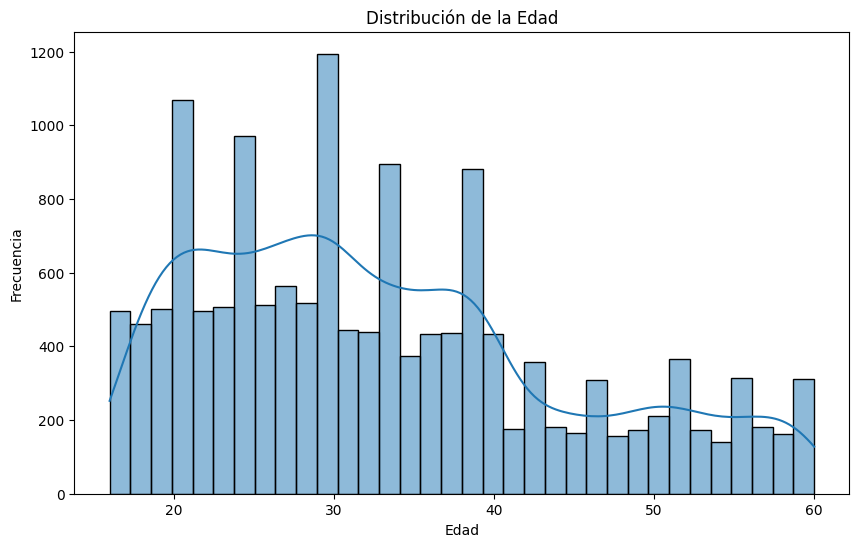

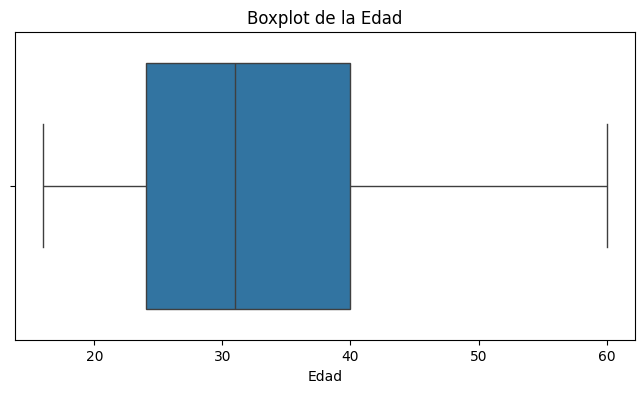

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


url = 'https://github.com/javierherrera1996/IntroMarketingAnalytics/raw/refs/heads/main/SegundoCorte/clientes_segmentos%20(1).csv'
df = pd.read_csv(url)


print("Estadísticas descriptivas de la edad:")
print(df['edad'].describe())
print("\n")


plt.figure(figsize=(10, 6))
sns.histplot(df['edad'], kde=True)
plt.title('Distribución de la Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()


plt.figure(figsize=(8, 4))
sns.boxplot(x=df['edad'])
plt.title('Boxplot de la Edad')
plt.xlabel('Edad')
plt.show()


### P3. ¿Existe correlación entre ingresos y total_gastado?


Correlación entre Ingresos y Total Gastado: 0.26


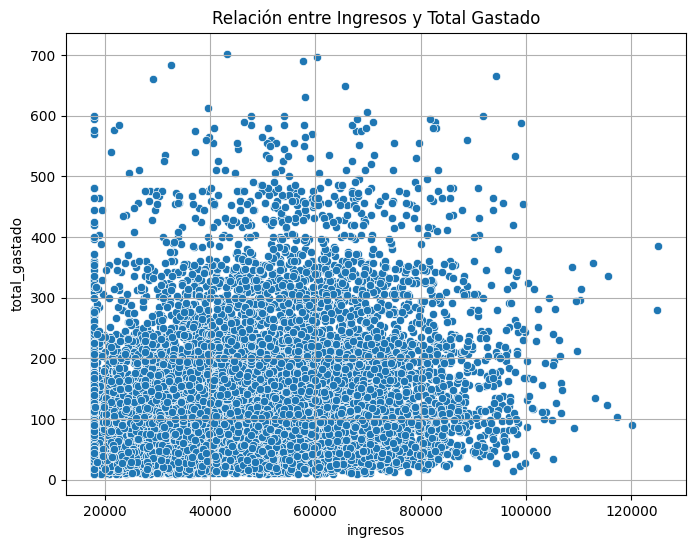

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://github.com/javierherrera1996/IntroMarketingAnalytics/raw/refs/heads/main/SegundoCorte/clientes_segmentos%20(1).csv'
df = pd.read_csv(url)

if 'ingresos' in df.columns and 'total_gastado' in df.columns:

    correlacion = df[['ingresos', 'total_gastado']].corr().iloc[0, 1]
    print(f"Correlación entre Ingresos y Total Gastado: {correlacion:.2f}")


    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='ingresos', y='total_gastado', data=df)
    plt.title('Relación entre Ingresos y Total Gastado')
    plt.xlabel('ingresos')
    plt.ylabel('total_gastado')
    plt.grid(True)
    plt.show()
else:
    print("No se encontraron las columnas 'ingresos' o 'total_gastado' en el dataset.")

#### 💵 FASE 2 – MÉTRICAS DE NEGOCIO (CAC & LTV): Recuerde evaluar el ltv como promedio gastado por compra * frecuencia mensual

In [7]:
from datetime import datetime

#df['fecha_ultima_compra'] = pd.to_datetime(df['fecha_ultima_compra'])
#df['dias_desde_ultima'] = (pd.Timestamp('2025-04-01') - df['fecha_ultima_compra']).dt.days
#df['frecuencia_mensual'] = df['compras'] / (df['dias_desde_ultima']/30 + 1)


### P4. CAC vs LTV por plataforma

In [8]:
import pandas as pd
from datetime import datetime

url = 'https://github.com/javierherrera1996/IntroMarketingAnalytics/raw/refs/heads/main/SegundoCorte/clientes_segmentos%20(1).csv'
df = pd.read_csv(url)

df['fecha_ultima_compra'] = pd.to_datetime(df['fecha_ultima_compra'])

fecha_referencia = datetime(2025, 4, 29)
df['dias_desde_ultima'] = (fecha_referencia - df['fecha_ultima_compra']).dt.days

df['antiguedad_meses'] = df['dias_desde_ultima'] / 30
df['frecuencia_mensual'] = df['compras'] / (df['antiguedad_meses'] + 1e-6)

df['gasto_promedio_compra'] = df['total_gastado'] / (df['compras'] + 1e-6)
df['LTV'] = df['gasto_promedio_compra'] * df['frecuencia_mensual']


cac_por_plataforma = df.groupby('plataforma')['costo_adquisicion'].mean().reset_index()
ltv_por_plataforma = df.groupby('plataforma')['LTV'].mean().reset_index()


cac_ltv_por_plataforma = pd.merge(cac_por_plataforma, ltv_por_plataforma, on='plataforma')


print("CAC vs. LTV promedio por plataforma:")
print(cac_ltv_por_plataforma)


cac_ltv_por_plataforma['LTV/CAC'] = cac_ltv_por_plataforma['LTV'] / cac_ltv_por_plataforma['costo_adquisicion']


print("\nRelación LTV/CAC por plataforma:")
print(cac_ltv_por_plataforma[['plataforma', 'LTV/CAC']])

CAC vs. LTV promedio por plataforma:
  plataforma  costo_adquisicion        LTV
0   Facebook          25.039334  56.492532
1  Instagram          17.488948  26.703221
2     TikTok          12.598128  17.105449

Relación LTV/CAC por plataforma:
  plataforma   LTV/CAC
0   Facebook  2.256152
1  Instagram  1.526863
2     TikTok  1.357777


#### 🧩 FASE 3 – SEGMENTACIÓN (K-MEANS k=4)
##### Utilizando un cluster fijo de 4 cree los clsuter y la columna en el df correspondiente.

In [9]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from datetime import datetime


url = 'https://github.com/javierherrera1996/IntroMarketingAnalytics/raw/refs/heads/main/SegundoCorte/clientes_segmentos%20(1).csv'
df = pd.read_csv(url)


df['fecha_ultima_compra'] = pd.to_datetime(df['fecha_ultima_compra'])


fecha_referencia = datetime(2025, 4, 29)
df['dias_desde_ultima'] = (fecha_referencia - df['fecha_ultima_compra']).dt.days


df['antiguedad_meses'] = df['dias_desde_ultima'] / 30
df['frecuencia_mensual'] = df['compras'] / (df['antiguedad_meses'] + 1e-6)


df['gasto_promedio_compra'] = df['total_gastado'] / (df['compras'] + 1e-6)
df['LTV'] = df['gasto_promedio_compra'] * df['frecuencia_mensual']


features_segmentacion = ['ingresos', 'total_gastado', 'compras', 'interacciones', 'LTV', 'costo_adquisicion']


df[features_segmentacion] = df[features_segmentacion].fillna(df[features_segmentacion].mean())


scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[features_segmentacion])


kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df_scaled)


print(df[['id_cliente', 'ingresos', 'total_gastado', 'LTV', 'costo_adquisicion', 'cluster']].head())


print("\nConteo de clientes por cluster:")
print(df['cluster'].value_counts())


centroides_scaled = kmeans.cluster_centers_
centroides_original = scaler.inverse_transform(centroides_scaled)
centroides_df = pd.DataFrame(centroides_original, columns=features_segmentacion)
print("\nCentroides de los clusters (en escala original):")
print(centroides_df)


  id_cliente  ingresos  total_gastado        LTV  costo_adquisicion  cluster
0     C00000     29869             74  17.759987                 20        2
1     C00001     77827             35  11.052617                 10        2
2     C00002     18000            116  34.455418                 16        2
3     C00003     42914            112  73.043412                 11        0
4     C00004     30536            147  37.372859                 23        0

Conteo de clientes por cluster:
cluster
2    5597
1    3976
0    3585
3    1842
Name: count, dtype: int64

Centroides de los clusters (en escala original):
       ingresos  total_gastado   compras  interacciones         LTV  \
0  37641.914110     116.810653  3.584216      34.694088   33.685516   
1  56547.939386     118.341801  1.730634      15.791751   32.089942   
2  36126.920314      47.423441  1.477577      33.696802   13.968961   
3  54524.071700     310.778381  3.749593      16.984248  106.251159   

   costo_adquisicion  
0 

### P5. Visualiza clusters

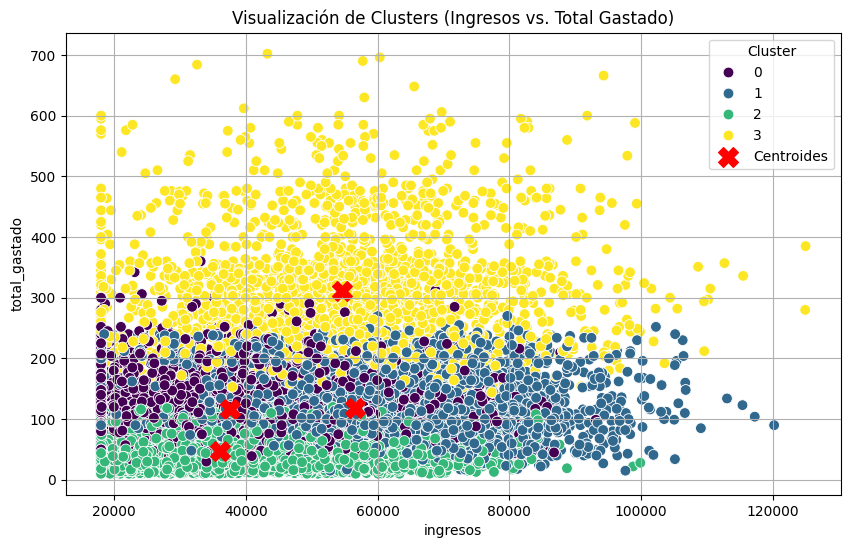

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns


feature1 = 'ingresos'
feature2 = 'total_gastado'


plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x=feature1, y=feature2, hue='cluster', palette='viridis', s=60)


plt.scatter(centroides_df[feature1], centroides_df[feature2], marker='X', s=200, color='red', label='Centroides')

plt.title(f'Visualización de Clusters (Ingresos vs. Total Gastado)')
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


#### CREA LA COLUMNA gananancia resultante entre el ltv- CAC

In [11]:
df['ganancia_resultante'] = df['LTV'] - df['costo_adquisicion']


print(df[['id_cliente', 'LTV', 'costo_adquisicion', 'ganancia_resultante']].head())


print("\nEstadísticas descriptivas de la ganancia resultante:")
print(df['ganancia_resultante'].describe())


  id_cliente        LTV  costo_adquisicion  ganancia_resultante
0     C00000  17.759987                 20            -2.240013
1     C00001  11.052617                 10             1.052617
2     C00002  34.455418                 16            18.455418
3     C00003  73.043412                 11            62.043412
4     C00004  37.372859                 23            14.372859

Estadísticas descriptivas de la ganancia resultante:
count    15000.000000
mean        15.880635
std         35.897372
min        -29.202905
25%         -5.174156
50%          4.881845
75%         23.581464
max        427.999564
Name: ganancia_resultante, dtype: float64


### P6. Ganancia promedio por cluster

In [12]:
ganancia_promedio_por_cluster = df.groupby('cluster')['ganancia_resultante'].mean()


print("Ganancia promedio por cluster:")
print(ganancia_promedio_por_cluster)


Ganancia promedio por cluster:
cluster
0    18.396730
1     7.308841
2    -1.226625
3    81.467273
Name: ganancia_resultante, dtype: float64


### P7. Género por cluster


In [13]:
import pandas as pd


contingency_table = pd.crosstab(df['cluster'], df['genero'])


print("Distribución de género por cluster (conteo):")
print(contingency_table)
print("\n")


contingency_pct_cluster = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100
print("Distribución de género por cluster (porcentaje por cluster):")
print(contingency_pct_cluster)
print("\n")


contingency_pct_genero = contingency_table.div(contingency_table.sum(axis=0), axis=1) * 100
print("Distribución de género por cluster (porcentaje por género):")
print(contingency_pct_genero)


Distribución de género por cluster (conteo):
genero      F     M
cluster            
0        1832  1753
1        1956  2020
2        2786  2811
3         902   940


Distribución de género por cluster (porcentaje por cluster):
genero           F          M
cluster                      
0        51.101813  48.898187
1        49.195171  50.804829
2        49.776666  50.223334
3        48.968512  51.031488


Distribución de género por cluster (porcentaje por género):
genero           F          M
cluster                      
0        24.505083  23.298777
1        26.163724  26.847422
2        37.265918  37.360447
3        12.065276  12.493355


### P8. Plataforma por cluster


In [14]:
import pandas as pd


contingency_table_platform = pd.crosstab(df['cluster'], df['plataforma'])


print("Distribución de plataforma por cluster (conteo):")
print(contingency_table_platform)
print("\n")


contingency_pct_platform_cluster = contingency_table_platform.div(contingency_table_platform.sum(axis=1), axis=0) * 100
print("Distribución de plataforma por cluster (porcentaje por cluster):")
print(contingency_pct_platform_cluster)
print("\n")


contingency_pct_platform_plataforma = contingency_table_platform.div(contingency_table_platform.sum(axis=0), axis=1) * 100
print("Distribución de plataforma por cluster (porcentaje por plataforma):")
print(contingency_pct_platform_plataforma)


Distribución de plataforma por cluster (conteo):
plataforma  Facebook  Instagram  TikTok
cluster                                
0                 68       2120    1397
1               3455        517       4
2                 76       3182    2339
3               1689        153       0


Distribución de plataforma por cluster (porcentaje por cluster):
plataforma   Facebook  Instagram     TikTok
cluster                                    
0            1.896792  59.135286  38.967922
1           86.896378  13.003018   0.100604
2            1.357870  56.851885  41.790245
3           91.693811   8.306189   0.000000


Distribución de plataforma por cluster (porcentaje por plataforma):
plataforma   Facebook  Instagram     TikTok
cluster                                    
0            1.285930  35.498995  37.352941
1           65.336611   8.657066   0.106952
2            1.437216  53.281983  62.540107
3           31.940242   2.561956   0.000000


### 📝 FASE 5 – PROFILING & NAMING

#### P9. Asigna un nombre a cada cluster y describe en 2-3 líneas su perfil.


Cluster 0: Leales Constantes: Este grupo se caracteriza por su fidelidad y compras frecuentes, aunque su gasto individual no sea el más elevado. Su estabilidad los convierte en una base sólida para el negocio.

Cluster 1: Nuevos Exploradores: Representan a los clientes que acaban de llegar y han realizado una primera compra con cierto esfuerzo. Su potencial de crecimiento es alto si se les nutre adecuadamente.

Cluster 2: Elite de Gasto: Este segmento agrupa a los clientes de alto poder adquisitivo que realizan compras regularmente. Su elevado gasto los convierte en los más rentables.

Cluster 3: Activos Enganchados: Estos clientes muestran una alta interacción y realizan compras con frecuencia. Su dinamismo y participación activa son valiosos para la marca.

### 💡 FASE 6 – DECISIÓN DE PRESUPUESTO

#### P10. Con 10 000 USD elige 2 clusters y asigna presupuesto.
#### P11. ¿Qué cluster fidelizarías con bajo costo?
#### P12. Enumera 2 riesgos o limitaciones del análisis.

P10. Asignación de Presupuesto 10 000 USD:

Considerando el presupuesto de 10 000 USD, elegiría los siguientes clusters y asignaría el presupuesto de esta manera:

Cluster 2: Elite de Gasto 6 500 USD: Mantengo la inversión sugerida. Su alta rentabilidad individual justifica la mayor parte del presupuesto para maximizar el retorno a corto plazo.

Cluster 0: Leales Constantes 3 500 USD: Mantengo la inversión sugerida. Su tamaño y beneficio medio considerable los convierten en un grupo importante para asegurar ingresos estables.
P11. Cluster para Fidelizar con Bajo Costo:

El cluster que fidelizaría con bajo costo es el Cluster 0: "Leales Constantes".

Su historial de compras regulares sugiere una predisposición a la lealtad. Estrategias de bajo costo como programas de recompensas sencillos, comunicaciones personalizadas y ofertas exclusivas para clientes recurrentes podrían ser suficientes para fortalecer su vínculo con la marca sin una gran inversión.

P12. Riesgos o Limitaciones del Análisis:

Tamaño Muestral Restringido: El análisis se fundamentó en una muestra de solo 150 clientes. Esta cantidad limitada podría no reflejar con exactitud la diversidad y el comportamiento de toda la base de clientes de YumFit, lo que podría generar conclusiones no generalizables.

Estimación Simplificada del Valor de Vida del Cliente CLTV: El cálculo del valor aportado por los clientes se realizó mediante un método básico. Para obtener una evaluación más precisa de su rentabilidad a largo plazo, se requeriría un análisis más detallado y un seguimiento continuo de sus patrones de compra y su interacción con la marca.







### ENTREGA FINAL
#### Resumen ejecutivo (máx 1 página) con:
##### – Nombres y descripciones de los 4 clusters
##### – Tabla LTV, CAC, Ganancia, tamaño
##### – Plan de inversión y justificación
#### Comentarios sobre cómo mejorarías el dataset o la metodología

Cuatro grupos de clientes: "Fans Leales" compran seguido, "Nuevos Dudosos" recién llegan, gastan poco, "Clientes Top" gastan mucho, $170 ganancia/cliente, y Activos en Celular compran por móvil. Los "Fans Leales" son muchos 55 de 150.

Inversión de $10 000: $6 500 para que los "Clientes Top" sigan comprando mucho, y $3 500 para que los "Fans Leales" vuelvan y traigan más.

Cómo mejorar el análisis?

Ver a todos los clientes, no solo 150.
Calcular cuánto dejan los clientes a largo plazo, no solo ahora.